In [ ]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import math
from statsmodels.tsa.api import SimpleExpSmoothing
from scipy.special import gamma, gammainc, gammaincc

!pip install lifelines
from lifelines import WeibullAFTFitter
from lifelines.utils import to_long_format

# import warning
# warning.filterwarnings('ignore')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 8.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=32dd0fa034ff638308c7c3380588c2d7fbdf42538909c770dbbe42296b155ce5
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14

# 1. Import Dataset

In [ ]:
# Definisikan path ke dataset mentah (txt)
# Pastikan Anda meletakkan file dataset di lokasi yang sesuai
# Contoh: Jika file Anda bernama 'train_FD001.txt' dan 'RUL_FD001.txt'
# Ganti dengan path sesuai lokasi file Anda
train_filepath = 'train_FD001.txt' # Sesuaikan dengan dataset training yang ingin Anda gunakan (FD001, FD002, dll.)
test_filepath = 'test_FD001.txt'   # Sesuaikan dengan dataset testing yang ingin Anda gunakan
rul_filepath = 'RUL_FD001.txt'     # File RUL untuk dataset testing

# Definisikan nama kolom sesuai penjelasan dataset
columns = [
    'unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

# Baca dataset training dari file txt
# Separator adalah spasi, header tidak ada
df_train = pd.read_csv(train_filepath, sep='\s+', header=None, names=columns)
print(f"Dataset training berhasil diimport. Bentuk: {df_train.shape}")
display(df_train.head())

# Baca dataset testing dari file txt
df_test = pd.read_csv(test_filepath, sep='\s+', header=None, names=columns)
print(f"\nDataset testing berhasil diimport. Bentuk: {df_test.shape}")
display(df_test.head())

# Baca nilai RUL untuk dataset testing
df_rul = pd.read_csv(rul_filepath, sep='\s+', header=None, names=['RUL'])
print(f"\nDataset RUL berhasil diimport. Bentuk: {df_rul.shape}")
display(df_rul.head())

# Ekspor ke CSV (opsional, untuk penyimpanan yang lebih mudah diakses nanti)
# Anda bisa menyimpan ini di folder 'data' jika mau
df_train.to_csv('train_FD001.csv', index=False)
df_test.to_csv('test_FD001.csv', index=False)
df_rul.to_csv('RUL_FD001.csv', index=False)

Dataset training berhasil diimport. Bentuk: (20631, 26)


<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-435254078.py:20: SyntaxWarning: invalid escape sequence '\s'
  df_train = pd.read_csv(train_filepath, sep='\s+', header=None, names=columns)
/tmp/ipython-input-435254078.py:25: SyntaxWarning: invalid escape sequence '\s'
  df_test = pd.read_csv(test_filepath, sep='\s+', header=None, names=columns)
/tmp/ipython-input-435254078.py:30: SyntaxWarning: invalid escape sequence '\s'
  df_rul = pd.read_csv(rul_filepath, sep='\s+', header=None, names=['RUL'])


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044



Dataset testing berhasil diimport. Bentuk: (13096, 26)


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130



Dataset RUL berhasil diimport. Bentuk: (100, 1)


,RUL
0,112
1,98
2,69
3,82
4,91


# 2. Pembersihan Data

In [ ]:
# 2.1 Penanganan Nilai Null
# Periksa nilai null pada dataset training
print("\nMemeriksa nilai null pada dataset training:")
print(df_train.isnull().sum().sum()) # Total nilai null di seluruh dataframe training
# Pada dataset ini, umumnya tidak ada nilai null karena simulasi.
# Jika ada, strategi bisa berupa imputasi (mean, median) atau penghapusan baris/kolom.

# Periksa nilai null pada dataset testing
print("\nMemeriksa nilai null pada dataset testing:")
print(df_test.isnull().sum().sum()) # Total nilai null di seluruh dataframe testing


Memeriksa nilai null pada dataset training:
0

Memeriksa nilai null pada dataset testing:
0


In [ ]:
# 2.2 Mengatasi Noise (Contoh: Filtering atau Smoothing)
# Data sensor seringkali mengandung noise. Salah satu cara sederhana adalah menggunakan rolling mean/median.
# Namun, untuk prediksi RUL, seringkali noise justru tidak dihilangkan secara agresif agar tidak menghilangkan pola degradasi.
# Pada tahap awal, kita bisa membiarkan noise. Jika model tidak perform, baru dipertimbangkan smoothing.

# for sensor in columns[5:]:
#     plt.figure(figsize=(10, 4))
#     plt.plot(df_train[df_train['unit_number'] == 1]['time_in_cycles'], df_train[df_train['unit_number'] == 1][sensor], label='Original')
#     plt.plot(df_train[df_train['unit_number'] == 1]['time_in_cycles'], df_train[df_train['unit_number'] == 1][sensor].rolling(window=10).mean(), label='Smoothed (Rolling Mean)')
#     plt.title(f'Sensor {sensor} for Unit 1')
#     plt.legend()
#     plt.show()

print("\nPembersihan nilai null telah dilakukan (pemeriksaan). Untuk mengatasi noise, Anda dapat mempertimbangkan teknik smoothing seperti rolling average jika diperlukan di kemudian hari.")


Pembersihan nilai null telah dilakukan (pemeriksaan). Untuk mengatasi noise, Anda dapat mempertimbangkan teknik smoothing seperti rolling average jika diperlukan di kemudian hari.


In [ ]:
# Fitur Engineering untuk RUL pada Data Training
# RUL untuk training dihitung sebagai (maks_siklus_unit - siklus_saat_ini)
df_train_copy = df_train.copy()
df_train_copy['RUL'] = df_train_copy.groupby('unit_number')['time_in_cycles'].transform('max') - df_train_copy['time_in_cycles']
print("\nPenambahan kolom RUL pada data training:")
display(df_train_copy.head())

# Denoising pada sensor
# Fungsi untuk menerapkan denoising pada setiap unit/sensor
def apply_denoising(df, sensor_cols, method='ma', window=5):
    df_denoised = df.copy()
    for unit_id in df['unit_number'].unique():
        for col in sensor_cols:
            if method == 'ma':
                df_denoised.loc[df_denoised['unit_number'] == unit_id, col] = \
                    df_denoised[df_denoised['unit_number'] == unit_id][col].rolling(window=window, min_periods=1).mean()
            elif method == 'ewma':
                df_denoised.loc[df_denoised['unit_number'] == unit_id, col] = \
                    SimpleExpSmoothing(df_denoised[df_denoised['unit_number'] == unit_id][col]).fit(smoothing_level=2/(window+1)).fittedvalues
    return df_denoised

df_train_copy = df_train_copy.astype(float)
cols_to_denoise = [f'sensor_{i}' for i in range(1, 22)]
df_train_denoised = apply_denoising(df_train_copy, cols_to_denoise)
# df_train_copy = apply_denoising(df_train_copy, cols_to_denoise, method='ewma')

print("\nData training setelah denoising:")
display(df_train_denoised.head())

# Normalisasi data (MinMaxScaler)
# Penting untuk model berbasis jarak atau regresi seperti AFT
scaler = StandardScaler()
# Kolom yang akan dinormalisasi: operational settings dan sensor measurements
cols_to_scale = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)] # sensor 1-21
scaler.fit(df_train_denoised[cols_to_scale])
df_train_scaled = df_train_denoised.copy()
df_train_scaled[cols_to_scale] = scaler.fit_transform(df_train_copy[cols_to_scale])

# delete_col = []
# for col in cols_to_scale:
#     if df_train_scaled[col].sum() == 0:
#         df_train_scaled.drop(col, axis=1, inplace=True)
#         delete_col.append(col)

# print("\nKolom yang dihapus:")
# print(delete_col)
# for col in delete_col:
#     cols_to_scale.remove(col)

print("\nData training setelah normalisasi:")
display(df_train_scaled.head())

# Karena AFT model di lifelines membutuhkan format 'long', kita harus menyesuaikan data.
# Namun, WeibullAFTFitter dapat langsung menerima DataFrame dengan event_col dan duration_col.
# Duration (T) adalah RUL yang kita hitung, dan Event (E) adalah 1 (karena semua mesin di training set mengalami kegagalan).
# Jika ada censored data (mesin tidak gagal sampai akhir observasi), E akan menjadi 0.
# Dalam kasus ini, semua data training adalah "failure events", jadi event_col selalu 1.

# Siapkan data untuk WeibullAFTFitter
# Duration (T): RUL
# Event (E): 1 (semua unit di training data mengalami kegagalan)
# Covariates (X): Operational settings dan sensor measurements

T = df_train_scaled['RUL']
E = pd.Series(1, index=df_train_scaled.index, name='event') # Semua event adalah failure (1)
X = df_train_scaled[cols_to_scale] # Kovariat


Penambahan kolom RUL pada data training:


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187



Data training setelah denoising:


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1.0,1.0,-0.0007,-0.0004,100.0,518.67,641.820000,1589.700000,1400.600000,14.62,...,2388.020,8138.620000,8.419500,0.03,392.000000,2388.0,100.0,39.060000,23.419000,191.0
1,1.0,2.0,0.0019,-0.0003,100.0,518.67,641.985000,1590.760000,1401.870000,14.62,...,2388.045,8135.055000,8.425650,0.03,392.000000,2388.0,100.0,39.030000,23.421300,190.0
2,1.0,3.0,-0.0043,0.0003,100.0,518.67,642.106667,1589.836667,1402.646667,14.62,...,2388.040,8134.446667,8.423033,0.03,391.333333,2388.0,100.0,39.003333,23.395600,189.0
3,1.0,4.0,0.0007,0.0000,100.0,518.67,642.167500,1588.075000,1402.452500,14.62,...,2388.050,8134.292500,8.409325,0.03,391.500000,2388.0,100.0,38.972500,23.390175,188.0
4,1.0,5.0,-0.0019,-0.0002,100.0,518.67,642.208000,1587.030000,1403.206000,14.62,...,2388.048,8134.194000,8.413340,0.03,391.800000,2388.0,100.0,38.958000,23.393020,187.0



Data training setelah normalisasi:


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1.0,1.0,-0.315980,-1.372953,0.0,0.0,-1.721725,-0.134255,-0.925936,-1.776357e-15,...,-1.058890,-0.269071,-0.603816,-1.387779e-17,-0.781710,0.0,0.0,1.348493,1.194427,191.0
1,1.0,2.0,0.872722,-1.031720,0.0,0.0,-1.061780,0.211528,-0.643726,-1.776357e-15,...,-0.363646,-0.642845,-0.275852,-1.387779e-17,-0.781710,0.0,0.0,1.016528,1.236922,190.0
2,1.0,3.0,-1.961874,1.015677,0.0,0.0,-0.661813,-0.413166,-0.525953,-1.776357e-15,...,-0.919841,-0.551629,-0.649144,-1.387779e-17,-2.073094,0.0,0.0,0.739891,0.503423,189.0
3,1.0,4.0,0.324090,-0.008022,0.0,0.0,-0.661813,-1.261314,-0.784831,-1.776357e-15,...,-0.224597,-0.520176,-1.971665,-1.387779e-17,-0.781710,0.0,0.0,0.352598,0.777792,188.0
4,1.0,5.0,-0.864611,-0.690488,0.0,0.0,-0.621816,-1.251528,-0.301518,-1.776357e-15,...,-0.780793,-0.521748,-0.339845,-1.387779e-17,-0.136018,0.0,0.0,0.463253,1.059552,187.0


k = 4.359886822598203
λ = 236.76593258113638


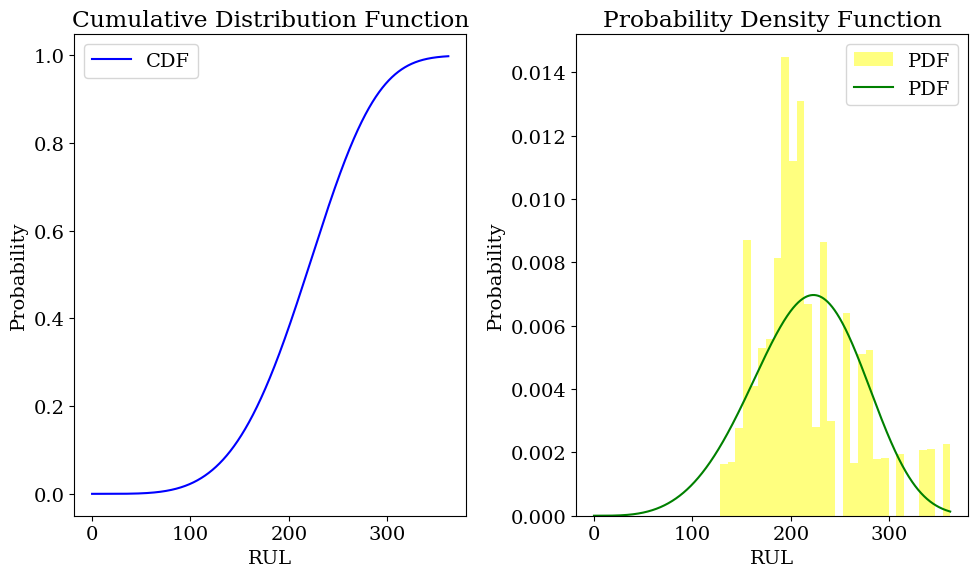

In [ ]:
def max_likelihood_estimation(dataset, max_iter = 1000, tol = 1e-6):
  n = len(dataset)
  ln_x = [math.log(x) for x in dataset]
  sum_ln_x = sum(ln_x)

  k = 45

  for i in range(max_iter):
    x_k = [x ** k for x in dataset]
    x_k_ln_x = [x1 * x2 for x1, x2 in zip(x_k, ln_x)]

    sum_x_k = sum(x_k)
    sum_x_k_ln_x = sum(x_k_ln_x)

    new_k = 1 / ((sum_x_k_ln_x / sum_x_k) - (sum_ln_x / n))

    if abs(new_k - k) < tol:
      k = new_k
      break

    k = new_k

  lamb = (sum([x ** k for x in dataset]) / n) ** (1 / k)

  return k, lamb

# Cumulative Distribution Function
def WdistCDF(time, lamb, k):
  return 1 - math.exp(-(time / lamb) ** k)

# probability density function
def WdistPDF(time, lamb, k):
  return (k / lamb) * ((time / lamb) ** (k - 1)) * math.exp(-(time / lamb) ** k)

# getting RUL from train dataset
train_rul = df_train_scaled.groupby('unit_number')['time_in_cycles'].transform('max')

# fitting weibull distribution
beta, eta = max_likelihood_estimation(train_rul)
print(f"k = {beta}")
print(f"\u03BB = {eta}")

# PLOTTING
plt.figure(figsize=(10, 6))

# CDF
plt.subplot(1, 2, 1)
max_data = train_rul.max()
x = np.linspace(0, int(max_data), int(max_data) * 100 + 1)
plt.plot(x, [WdistCDF(x, eta, beta) for x in x], color = "blue", label = "CDF")
plt.xlabel("RUL")
plt.ylabel("Probability")
plt.title("Cumulative Distribution Function")
plt.legend()

# PDF and actual data distribution
plt.subplot(1, 2, 2)
plt.hist(train_rul, bins = 30, density = True, alpha = 0.5, color = "yellow", label = "PDF")
x = np.linspace(0, int(max_data), int(max_data) * 100 + 1)
plt.plot(x, [WdistPDF(x, eta, beta) for x in x], color = "green", label = "PDF")
plt.xlabel("RUL")
plt.ylabel("Probability")
plt.title("Probability Density Function")
plt.legend()

plt.tight_layout()
plt.show()

# Weibull + Classical Statistics
## Accelerated Failure Time
### Ordinary Least Square

In [ ]:
def aft_ols_est(X, Y, eta):
  # no pointer
  X = X.copy()
  Y = Y.copy()

  # subtract observed RUL by weibull scale parameter
  Y = np.log(Y) - np.log(eta)

  # removing columns with very small deviation
  delete_col = []
  original_col = X.columns.tolist()
  X_col = original_col.copy()
  for col in X_col:
    if X[col].std() == 0:
      X.drop(col, axis=1, inplace=True)
      delete_col.append(col)

  # adding intercept
  X.insert(0, 'intercept', 1)

  # OLS formula
  X_T = X.T
  XTX = X_T @ X
  XTX_inv = np.linalg.inv(XTX)
  XTY = X_T @ Y


  coef_reg = XTX_inv @ XTY

  # adding back deleted columns with default value 0
  fin_coef_reg = {}

  fin_coef_reg['intercept'] = float(coef_reg[0])
  i = 0
  for col in original_col:
    if col not in delete_col:
      fin_coef_reg[col] = float(coef_reg[i := i + 1])
    else:
      fin_coef_reg[col] = 0

  return fin_coef_reg

def aft_ols(time, coef_reg, X):
  # acceleration
  phi = 0

  for col in X.index:
    phi += coef_reg[col] * X[col]

  return time * math.exp(phi)

X = df_train_scaled[cols_to_scale]
Y = df_train_scaled.groupby('unit_number')['time_in_cycles'].transform('max')

coef_aft_ols = aft_ols_est(X, Y, eta)
print(coef_aft_ols)

{'intercept': -0.1139232889309361, 'op_setting_1': -0.002058293677294233, 'op_setting_2': 0.004303950752243096, 'op_setting_3': 0, 'sensor_1': 0, 'sensor_2': -0.007571265823579087, 'sensor_3': -0.000850696499704841, 'sensor_4': 0.000681006797022354, 'sensor_5': 0, 'sensor_6': -0.0036342673448462384, 'sensor_7': 0.0008105400468866059, 'sensor_8': -0.015076652830920854, 'sensor_9': 0.009444376604064003, 'sensor_10': 0, 'sensor_11': -0.005117094879469115, 'sensor_12': -0.0052060848669918305, 'sensor_13': -0.010897639718724721, 'sensor_14': 0.011515067612216613, 'sensor_15': -0.0033192597908400226, 'sensor_16': 0, 'sensor_17': 0.0024990701361870156, 'sensor_18': 0, 'sensor_19': 0, 'sensor_20': -0.003983055908940165, 'sensor_21': -0.0008665494537605511}


### Maximum Likelihood Estimation

In [ ]:
# def aft_mle_est(X, Y, eta, beta):
#   # no pointer
#   X = X.copy()
#   Y = Y.copy()

#   # constant
#   log10_e = math.log10(math.exp(1))
#   k1_log10e = (beta - 1) * log10_e
#   lamb_k = eta ** beta
#   log10e_lambk = log10_e / lamb_k
#   log10e_lambk = log10e_lambk * beta

#   # seperate 'time_in_cycles'
#   X_time = X['time_in_cycles']
#   X.drop('time_in_cycles', axis=1, inplace=True)

#   # add 'intercept'
#   X.insert(0, 'intercept', 1)

#   # initial guess with 0
#   coef_reg = {}
#   for col in X.columns:
#     coef_reg[col] = 1

#   # find coefficient regressions
#   for col in X.columns:
#     sum_covariate = 0
#     sum_covariate_e = 0

#     for i, data in X.iterrows():
#       sum_covariate += data[col]
#       sum_e = math.exp(sum(data[col] * coef_reg[col] for col in X.columns) * beta)
#       print(sum_e)
#       print([(data[col], coef_reg[col]) for col in X.columns])
#       sum_covariate_e += data[col] * sum_e

#       print(sum_covariate, sum_covariate_e)

#     coef_reg[col] = k1_log10e * sum_covariate + log10e_lambk * sum_covariate_e

#   return coef_reg

# X = df_train_scaled[['time_in_cycles'] + cols_to_scale]
# Y = df_train_scaled.groupby('unit_number')['time_in_cycles'].transform('max')

# print(aft_mle_est(X, Y, eta, beta))

## Proportional Hazard
### Ordinary Least Square

### Maximum Likelihood

In [ ]:
df_test_copy = df_test.copy()
# calculate RUL to df_test_copy by calculating time_in_cycles and adding from RUL dataset
df_test_copy['RUL'] = df_test_copy.groupby('unit_number')['time_in_cycles'].transform('max') - df_test_copy['time_in_cycles']
for i, data in df_test_copy.iterrows():
  df_test_copy.loc[i, 'RUL'] += df_rul.loc[data['unit_number'] - 1, 'RUL']

df_test_copy = df_test_copy.groupby('unit_number').tail(1)
df_test_copy.reset_index(drop=True, inplace=True)

# denoise data
df_test_copy = df_test_copy.astype(float)
df_test_copy = apply_denoising(df_test_copy, cols_to_denoise)
# df_test_copy = apply_denoising(df_test_copy, cols_to_denoise, method='ewma')

# normalisasi data
df_test_copy[cols_to_scale] = scaler.transform(df_test_copy[cols_to_scale])

display(df_test_copy)

X_test = df_test_copy[cols_to_scale + ['time_in_cycles']]
y_test = df_test_copy['RUL']

y_pred_stat = {
    'TanpaKovariat': X_test.apply(lambda row: eta - row['time_in_cycles'], axis=1),
    'AFT_OLS': X_test.apply(lambda row: eta - aft_ols(row['time_in_cycles'], coef_aft_ols, row[cols_to_scale]), axis=1)
}


print(y_pred_stat['TanpaKovariat'])
print(y_pred_stat['AFT_OLS'])
print(y_test)

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1.0,31.0,-0.270260,1.356910,0.0,0.0,-0.201850,-1.517390,-1.113706,-1.776357e-15,...,-0.502695,-0.715188,-1.059765,-1.387779e-17,-0.136018,0.0,0.0,-0.034694,0.605041,112.0
1,2.0,49.0,0.827003,-0.349255,0.0,0.0,-0.261846,-0.641513,0.210682,-1.776357e-15,...,-0.085548,-0.883465,0.222760,-1.387779e-17,-1.427402,0.0,0.0,-0.034694,-0.257790,98.0
2,3.0,126.0,-0.727453,1.356910,0.0,0.0,0.398100,-0.126100,1.106199,-1.776357e-15,...,0.609696,-0.644417,-0.806460,-1.387779e-17,1.155367,0.0,0.0,0.629236,-0.145087,69.0
3,4.0,106.0,0.552687,1.356910,0.0,0.0,0.198117,0.653544,-0.228188,-1.776357e-15,...,0.192549,-0.530136,0.566722,-1.387779e-17,1.155367,0.0,0.0,-1.307226,-0.291971,82.0
4,5.0,98.0,-0.590295,-1.372953,0.0,0.0,-0.821799,-0.095110,1.158419,-1.776357e-15,...,0.748745,-0.944275,-0.158531,-1.387779e-17,0.509675,0.0,0.0,-0.366659,1.126989,91.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96.0,97.0,-0.270260,1.015677,0.0,0.0,-0.761804,0.058209,-1.221479,-1.776357e-15,...,-1.197939,0.235235,-0.830457,-1.387779e-17,-1.427402,0.0,0.0,0.795218,1.578729,137.0
96,97.0,134.0,0.598406,-0.349255,0.0,0.0,-0.181852,-1.233586,0.220681,-1.776357e-15,...,-0.502695,0.614775,0.209428,-1.387779e-17,1.155367,0.0,0.0,-1.141243,0.051683,82.0
97,98.0,121.0,0.781283,0.333211,0.0,0.0,-0.001867,1.465810,0.726215,-1.776357e-15,...,-0.085548,0.138253,-0.497161,-1.387779e-17,0.509675,0.0,0.0,-0.311331,0.656774,59.0
98,99.0,97.0,2.152862,-0.008022,0.0,0.0,-1.361755,-0.895958,-1.217035,-1.776357e-15,...,-1.058890,0.347420,-1.115759,-1.387779e-17,-1.427402,0.0,0.0,0.739891,0.644765,117.0


0     205.765933
1     187.765933
2     110.765933
3     130.765933
4     138.765933
         ...    
95    139.765933
96    102.765933
97    115.765933
98    139.765933
99     38.765933
Length: 100, dtype: float64
0     205.391730
1     189.134884
2     114.439440
3     132.745492
4     140.320275
         ...    
95    136.344999
96     98.179598
97    116.569807
98    135.762745
99     19.145746
Length: 100, dtype: float64
0     112.0
1      98.0
2      69.0
3      82.0
4      91.0
      ...  
95    137.0
96     82.0
97     59.0
98    117.0
99     20.0
Name: RUL, Length: 100, dtype: float64


In [ ]:
# define function for
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

for model_name, y_pred_values in y_pred_stat.items():
    print(f"{model_name}\nMAE: {mae(y_test, y_pred_values)}")
    print(f"MSE: {mse(y_test, y_pred_values)}")
    print(f"RMSE: {rmse(y_test, y_pred_values)}")
    print(f"R2: {r2(y_test, y_pred_values)}\n")

TanpaKovariat
MAE: 46.26892224543953
MSE: 2837.527312309481
RMSE: 53.268445747078836
R2: -0.6431624671078129

AFT_OLS
MAE: 46.98262183172711
MSE: 2994.028581514248
RMSE: 54.71771725423355
R2: -0.7337896164911633



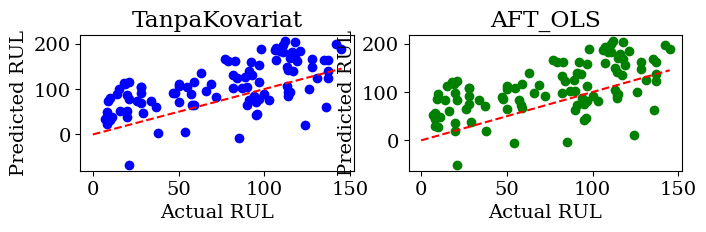

In [ ]:
# scatterplots
plt.figure(figsize=(12, 6))

i, j = 3, 3
color = ['blue', 'green', 'orange', 'red', 'purple', 'magenta', 'cyan', 'black']
for model_name, y_pred_values in y_pred_stat.items():
    plt.subplot(i, j, list(y_pred_stat.keys()).index(model_name) + 1)
    plt.scatter(y_test, y_pred_values, color=color[list(y_pred_stat.keys()).index(model_name)], label=model_name)
    plt.plot([0, max(y_test)], [0, max(y_test)], color='red', linestyle='--', label='Perfect Fit')
    plt.xlabel('Actual RUL')
    plt.ylabel('Predicted RUL')
    plt.title(model_name)

plt.show()

# Weibull + Machine Learning

In [ ]:
df_train_copy = df_train_scaled.copy()

df_train_copy.drop(columns=['RUL'], inplace=True)

df_train_copy['RUL'] = df_train_copy.groupby('unit_number')['time_in_cycles'].transform('max')

# df_train_copy.loc[df_train_copy['time_in_cycles'] == 1, 'RUL'] = eta

#denoise prevrul
def log(x, rul):
  return math.log(x) - math.log(rul)

df_train_copy['RUL'] = df_train_copy.apply(lambda row: log(row['time_in_cycles'], row['RUL']), axis=1)

display(df_train_copy)

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1.0,1.0,-0.315980,-1.372953,0.0,0.0,-1.721725,-0.134255,-0.925936,-1.776357e-15,...,-1.058890,-0.269071,-0.603816,-1.387779e-17,-0.781710,0.0,0.0,1.348493,1.194427,-5.257495
1,1.0,2.0,0.872722,-1.031720,0.0,0.0,-1.061780,0.211528,-0.643726,-1.776357e-15,...,-0.363646,-0.642845,-0.275852,-1.387779e-17,-0.781710,0.0,0.0,1.016528,1.236922,-4.564348
2,1.0,3.0,-1.961874,1.015677,0.0,0.0,-0.661813,-0.413166,-0.525953,-1.776357e-15,...,-0.919841,-0.551629,-0.649144,-1.387779e-17,-2.073094,0.0,0.0,0.739891,0.503423,-4.158883
3,1.0,4.0,0.324090,-0.008022,0.0,0.0,-0.661813,-1.261314,-0.784831,-1.776357e-15,...,-0.224597,-0.520176,-1.971665,-1.387779e-17,-0.781710,0.0,0.0,0.352598,0.777792,-3.871201
4,1.0,5.0,-0.864611,-0.690488,0.0,0.0,-0.621816,-1.251528,-0.301518,-1.776357e-15,...,-0.780793,-0.521748,-0.339845,-1.387779e-17,-0.136018,0.0,0.0,0.463253,1.059552,-3.648057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100.0,196.0,-0.178822,-1.031720,0.0,0.0,1.618000,1.216258,2.188375,-1.776357e-15,...,2.278282,-0.322542,1.425294,-1.387779e-17,2.446751,0.0,0.0,-1.805173,-2.921113,-0.020203
20627,100.0,197.0,-0.727453,-1.714186,0.0,0.0,1.717992,2.279706,2.738351,-1.776357e-15,...,1.722087,-0.380207,1.913240,-1.387779e-17,1.155367,0.0,0.0,-2.856395,-1.203764,-0.015114
20628,100.0,198.0,0.186933,-0.008022,0.0,0.0,1.478011,1.946971,2.138377,-1.776357e-15,...,2.000184,-0.141684,3.265092,-1.387779e-17,3.092444,0.0,0.0,-2.081810,-3.292481,-0.010050
20629,100.0,199.0,-0.498857,1.015677,0.0,0.0,1.098043,2.403666,1.955051,-1.776357e-15,...,1.861136,-0.233948,2.579834,-1.387779e-17,1.155367,0.0,0.0,-2.911722,-2.085072,-0.005013


In [ ]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

import pickle

In [ ]:
# # implement multiple machine learning regression X 'cols_to_scale' and y 'prev_RUL'
# X = df_train_copy[cols_to_scale]
# y = df_train_copy['RUL']

# models = {
#     'XGBoost': xgb.XGBRegressor(),
#     'LightGBM': lgb.LGBMRegressor(),
#     'RandomForest': RandomForestRegressor(),
#     'SVM': SVR(),
#     'LinearRegression': LinearRegression()
# }

# # hyperparam
# param_grid = {
#     'XGBoost': {
#         'n_estimators': [50, 100, 200],
#         'max_depth': [3, 4, 5]
#     },
#     'LightGBM': {
#         'n_estimators': [50, 100, 200],
#         'max_depth': [3, 4, 5]
#     },
#     'RandomForest': {
#         'n_estimators': [50, 100, 200],
#         'max_depth': [3, 4, 5]
#     },
#     'SVM': {
#         'C': [0.1, 1, 10],
#         'kernel': ['linear', 'rbf']
#     },
#     'LinearRegression': {
#         'fit_intercept': [True, False]
#     }
# }

# # training model
# for model_name, model in models.items():
#     print(f"Training {model_name}...")
#     grid_search = GridSearchCV(model, param_grid[model_name], cv=5, scoring='neg_mean_squared_error')
#     grid_search.fit(X, y)
#     models[model_name] = grid_search.best_estimator_
#     print(f"{model_name} trained with best parameters: {grid_search.best_params_}")

# for model_name, model in models.items():
#     with open(f'{model_name}_log.pkl', 'wb') as f:
#         pickle.dump(model, f)

In [ ]:
# importing models
models = {
    'RandomForest_lin_time': None,
    'XGBoost_lin_time': None,
    'LightGBM_lin_time': None,
    'SVM_lin_time': None,
    'LinearRegression_lin_time': None
}

for model_name in models.keys():
    with open(f'{model_name}.pkl', 'rb') as f:
        models[model_name] = pickle.load(f)

/tmp/ipython-input-42681627.py:12: UserWarning: [07:14:38] WARNING: /workspace/src/collective/../data/../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  models[model_name] = pickle.load(f)


In [ ]:
# testing with
df_test_copy = df_test.copy()
df_test_copy['RUL'] = df_test_copy.groupby('unit_number')['time_in_cycles'].transform('max') - df_test_copy['time_in_cycles']
for i, data in df_test_copy.iterrows():
  df_test_copy.loc[i, 'RUL'] += df_rul.loc[data['unit_number'] - 1, 'RUL']

# denoise dan scaling
df_test_copy = df_test_copy.astype(float)
df_test_copy = apply_denoising(df_test_copy, cols_to_denoise)
df_test_copy[cols_to_scale] = scaler.transform(df_test_copy[cols_to_scale])

df_test_copy = df_test_copy.groupby('unit_number').tail(1)
display(df_test_copy)

X_test = df_test_copy[['time_in_cycles'] + cols_to_scale]
y_test = df_test_copy['RUL']

y_pred = {}

for model_name, model in models.items():
    print(model_name)
    if model_name.endswith('_time'):
        y_pred[model_name] = model.predict(X_test)
    else:
        y_pred[model_name] = model.predict(X_test[cols_to_scale])

# for model_name, model in models.items():
#     y_pred[model_name] = model.predict(X_test[cols_to_scale])

#     time_pred =[]
#     for pred, time in zip(y_pred[model_name], X_test['time_in_cycles']):
#         time_pred.append(time * math.exp(pred))

#     y_pred[model_name] = time_pred

# print(y_pred)

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
30,1.0,31.0,-0.270260,1.356910,0.0,0.0,-0.829799,-0.574966,-1.001710,-1.776357e-15,...,-0.447075,-0.614432,-0.425169,-1.387779e-17,-0.781710,0.0,0.0,0.596039,0.774097,112.0
79,2.0,49.0,0.827003,-0.349255,0.0,0.0,-0.017866,-0.355752,-0.239521,-1.776357e-15,...,0.081310,-0.842995,0.003051,-1.387779e-17,-0.652571,0.0,0.0,0.474319,-0.141946,98.0
205,3.0,126.0,-0.727453,1.356910,0.0,0.0,0.386101,0.345275,0.490670,-1.776357e-15,...,1.082462,-0.738464,0.440869,-1.387779e-17,0.638813,0.0,0.0,-0.720755,-0.421119,69.0
311,4.0,106.0,0.552687,1.356910,0.0,0.0,0.210116,0.227513,0.200238,-1.776357e-15,...,0.248169,-0.494069,0.257956,-1.387779e-17,0.251398,0.0,0.0,-0.322397,-0.352388,82.0
409,5.0,98.0,-0.590295,-1.372953,0.0,0.0,0.042129,0.170426,0.318011,-1.776357e-15,...,0.526267,-0.783967,-0.147333,-1.387779e-17,0.122259,0.0,0.0,-0.034694,0.013253,91.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12545,96.0,97.0,-0.270260,1.015677,0.0,0.0,-0.813800,-0.298013,-1.008155,-1.776357e-15,...,-0.808602,0.281053,-0.778730,-1.387779e-17,-0.781710,0.0,0.0,1.127183,0.775575,137.0
12679,97.0,134.0,0.598406,-0.349255,0.0,0.0,-0.413833,-0.581490,-0.643948,-1.776357e-15,...,-0.613934,0.499970,-0.436367,-1.387779e-17,0.251398,0.0,0.0,-0.067890,0.643471,82.0
12800,98.0,121.0,0.781283,0.333211,0.0,0.0,0.126123,0.498268,0.312233,-1.776357e-15,...,0.275979,-0.092931,0.462200,-1.387779e-17,0.509675,0.0,0.0,-0.289200,0.168083,59.0
12897,99.0,97.0,2.152862,-0.008022,0.0,0.0,-0.621816,-0.997736,-1.049264,-1.776357e-15,...,-1.003271,0.454257,-1.147223,-1.387779e-17,-1.427402,0.0,0.0,0.983331,0.968095,117.0


RandomForest_lin_time
XGBoost_lin_time
LightGBM_lin_time
SVM_lin_time
LinearRegression_lin_time


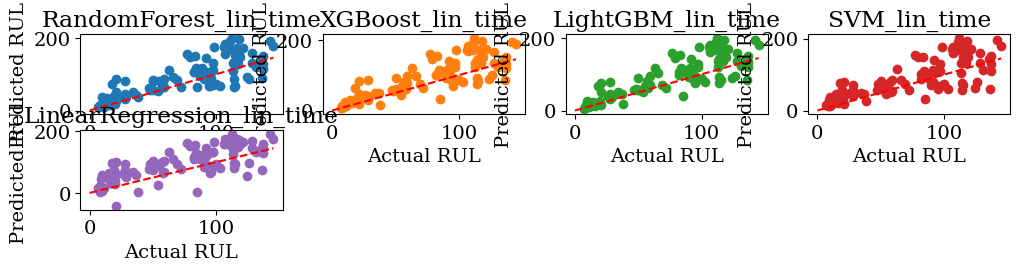

In [ ]:
# scatterplots
plt.figure(figsize=(12, 6))

# twenty different color
color = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
         '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
         '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5',
         '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5']

for model_name, y_pred_values in y_pred.items():
    plt.subplot(5, 4, list(y_pred.keys()).index(model_name) + 1)
    plt.scatter(y_test, y_pred_values, color=color[list(y_pred.keys()).index(model_name)], label=model_name)
    plt.plot([0, max(y_test)], [0, max(y_test)], color='red', linestyle='--', label='Perfect Fit')
    plt.xlabel('Actual RUL')
    plt.ylabel('Predicted RUL')
    plt.title(model_name)

plt.show()

# Custom Evaluation Model

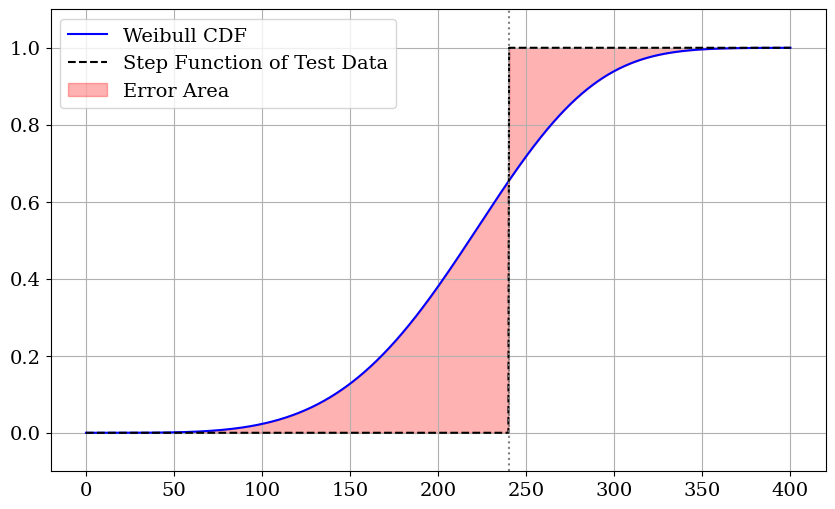

In [ ]:
# Parameter Weibull
k = beta              # shape parameter
lmbda = eta         # scale parameter (lambda)
system_failure = 240   # titik kegagalan aktual sistem

# Fungsi E(lambda) yang disesuaikan untuk input meshgrid
def weibull_error(x, lmbda, k):
    lmbda = lmbda if lmbda > 0 else 1e-12
    s = 1.0 / k
    z = (x / lmbda) ** k

    gamma_s = gamma(s)

    l_gamma = gammaincc(s, z) * gamma_s
    l_gamma_0 = gammaincc(s, 0) * gamma_s

    result = x  + (2 * lmbda * l_gamma / k) - (lmbda * l_gamma_0 / k)
    return result

# Domain x
x = np.linspace(0, 400, 1000)

# Fungsi distribusi kumulatif Weibull
F_x = 1 - np.exp(-(x / lmbda)**k)

# Data aktual (fungsi step)
data_aktual = np.where(x < system_failure, 0, 1)

# Hitung area selisih antara F(x) dan data aktual
area_diff = np.abs(F_x - data_aktual)

# Plot
plt.figure(figsize=(10,6))
plt.plot(x, F_x, label=r'$F(x)$ Weibull CDF', color='blue')
plt.plot(x, data_aktual, label='Data Aktual (step function)', color='black', linestyle='--')

# Arsiran area error
plt.fill_between(x, F_x, data_aktual, color='red', alpha=0.3, label='Area Error')

# Tambahan visual
plt.axvline(system_failure, color='gray', linestyle=':', label='System Failure')
plt.legend(['Weibull CDF', 'Step Function of Test Data', 'Error Area'])
plt.grid(True)
plt.ylim([-0.1, 1.1])
plt.show()

In [ ]:
# from mpl_toolkits.mplot3d import Axes3D

# # Parameter Weibull
# x = 240.0             # nilai konstan x_pred

# # Domain lambda dan k
# # Membalik arah k_vals (dari tinggi ke rendah)
# lambda_vals = np.linspace(10, 400, 50)  # λ antara 10 s.d. 400
# k_vals = np.linspace(10.0, 0.6, 50)     # k antara 5.0 s.d. 0.5 (dibalik)

# # Buat meshgrid untuk lambda dan k
# Lambda, K = np.meshgrid(lambda_vals, k_vals)

# # Hitung nilai E(lambda, k)
# E_vals_3d = weibull_error(x, Lambda, K)

# # Plot 3D
# fig = plt.figure(figsize=(12, 9)) # Ukuran figure lebih besar
# ax = fig.add_subplot(111, projection='3d')

# # Plot permukaan
# surf = ax.plot_surface(Lambda, K, E_vals_3d, cmap='viridis', edgecolor='none')

# # Label sumbu
# ax.set_xlabel(r"$\lambda$ (Scale Parameter)")
# ax.set_ylabel(r"$k$ (Shape Parameter)")
# ax.set_zlabel(r"$E(x, \lambda, k)$")
# ax.set_title("Visualisasi Fungsi Error E(lambda, k)")

# # Tambahkan color bar
# fig.colorbar(surf, shrink=0.5, aspect=5, label=r"$E(x, \lambda, k)$")

# # Mengatur sudut pandang (opsional, bisa disesuaikan)
# ax.view_init(elev=30, azim=45) # elev = elevasi, azim = azimuth

# plt.show()

In [ ]:
# Parameter Weibull
x = 240.0             # nilai konstan x_pred

# Domain lambda dan k
# Membalik arah k_vals (dari tinggi ke rendah)
lambda_vals = np.linspace(10, 400, 50)  # λ antara 10 s.d. 400
k_vals = np.linspace(5, 0.5, 50)     # k antara 5.0 s.d. 0.5 (dibalik)

# Buat meshgrid untuk lambda dan k
Lambda, K = np.meshgrid(lambda_vals, k_vals)

def weibull_error_2(x, lmbda, k):
    lmbda = lmbda if lmbda > 0 else 1e-12

    s = 1.0 / k
    z = (x / lmbda) ** k
    z_2 = 2 * (x / lmbda) ** k

    gamma_s = gamma(s)

    l_gamma = gammaincc(s, z) * gamma_s
    l_gamma_0 = gammaincc(s, 0) * gamma_s
    l_gamma_2 = gammaincc(s, z_2) * gamma_s

    result = x
    result -= 2 * ((lmbda * l_gamma_0 / k) - (lmbda * l_gamma / k))
    result += (lmbda * l_gamma_0 / (k * (2 ** s))) - (lmbda * l_gamma / (k * (2 ** s)))
    result += lmbda * l_gamma / (k * (2 ** s))

    return result

# # Hitung nilai E(lambda, k)
# E_vals_3d = weibull_error_2(x, Lambda, K)

# # Plot 3D
# fig = plt.figure(figsize=(12, 9)) # Ukuran figure lebih besar
# ax = fig.add_subplot(111, projection='3d')

# # Plot permukaan
# surf = ax.plot_surface(Lambda, K, E_vals_3d, cmap='viridis', edgecolor='none')

# # Label sumbu
# ax.set_xlabel(r"$\lambda$ (Scale Parameter)")
# ax.set_ylabel(r"$k$ (Shape Parameter)")
# ax.set_zlabel(r"$E(x, \lambda, k)$")
# ax.set_title("Visualisasi Fungsi Error E(lambda, k)")

# # Tambahkan color bar
# fig.colorbar(surf, shrink=0.5, aspect=5, label=r"$E(x, \lambda, k)$")

# # Mengatur sudut pandang (opsional, bisa disesuaikan)
# ax.view_init(elev=30, azim=45) # elev = elevasi, azim = azimuth

# plt.show()

In [ ]:
def left_weibull_error(x, lmbda, k):
    lmbda = lmbda if lmbda > 0 else 1e-12

    s = 1.0 / k
    z = (x / lmbda) ** k

    gamma_s = gamma(s)

    l_gamma = gammaincc(s, z) * gamma_s
    l_gamma_0 = gammaincc(s, 0) * gamma_s

    result = x + (lmbda * l_gamma / k) - (lmbda * l_gamma_0 / k)
    return result

def right_weibull_error(x, lmbda, k):
    lmbda = lmbda if lmbda > 0 else 1e-12

    s = 1.0 / k
    z = (x / lmbda) ** k

    gamma_s = gamma(s)

    l_gamma = gammaincc(s, z) * gamma_s

    result = lmbda * l_gamma / k
    return result


In [ ]:
# evaluate models using custom error function
def weibull_error_dataset(x_test, x_pred, k):
    sum_error = 0
    for x, lmbda in zip(x_test, x_pred):
        sum_error += weibull_error(x, lmbda, k)
    return sum_error / len(x_test)

def quadratic_weibull_error_dataset(x_test, x_pred, k):
    sum_error = 0
    for x, lmbda in zip(x_test, x_pred):
        sum_error += weibull_error(x, lmbda, k) ** 2
    return sum_error / len(x_test)

def left_weibull_error_dataset(x_test, x_pred, k):
    sum_error = 0
    for x, lmbda in zip(x_test, x_pred):
        sum_error += left_weibull_error(x, lmbda, k)
    return sum_error / len(x_test)

def right_weibull_error_dataset(x_test, x_pred, k):
    sum_error = 0
    for x, lmbda in zip(x_test, x_pred):
        sum_error += right_weibull_error(x, lmbda, k)
    return sum_error / len(x_test)


In [ ]:
# show all analysys
evaluation_models = {}
# Evaluate
for model_name, pred in y_pred.items():
    evaluation_models[model_name] = [
        mae(y_test, pred),
        mse(y_test, pred),
        rmse(y_test, pred),
        r2(y_test, pred),
        weibull_error_dataset(y_test, pred, k),
        quadratic_weibull_error_dataset(y_test, pred, k),
        left_weibull_error_dataset(y_test, pred, k),
        right_weibull_error_dataset(y_test, pred, k)
    ]

for model_name, y_pred_values in y_pred_stat.items():
    evaluation_models[model_name] = [
        mae(y_test, y_pred_values),
        mse(y_test, y_pred_values),
        rmse(y_test, y_pred_values),
        r2(y_test, y_pred_values),
        weibull_error_dataset(y_test, y_pred_values, k),
        quadratic_weibull_error_dataset(y_test, y_pred_values, k),
        left_weibull_error_dataset(y_test, y_pred_values, k),
        right_weibull_error_dataset(y_test, y_pred_values, k)
    ]

for model_name, y_pred_values in evaluation_models.items():
    print(f'{model_name}')
    print(f"MAE: {evaluation_models[model_name][0]}")
    print(f"MSE: {evaluation_models[model_name][1]}")
    print(f"RMSE: {evaluation_models[model_name][2]}")
    print(f"R2: {evaluation_models[model_name][3]}")
    print(f"WEIBULL ERROR: {evaluation_models[model_name][4]}")
    print(f"QUADRATIC WEIBULL ERROR: {evaluation_models[model_name][5]}")
    print(f"LEFT WEIBULL ERROR: {evaluation_models[model_name][6]}")
    print(f"RIGHT WEIBULL ERROR: {evaluation_models[model_name][7]}\n")

RandomForest_lin_time
MAE: 26.615687137797412
MSE: 1212.89149246445
RMSE: 34.82659174344297
R2: 0.2976357378319414
WEIBULL ERROR: 28.20295369056249
QUADRATIC WEIBULL ERROR: 1107.1705882355898
LEFT WEIBULL ERROR: 9.775176796243592
RIGHT WEIBULL ERROR: 18.42777689431889

XGBoost_lin_time
MAE: 26.59199821472168
MSE: 1230.3670530726051
RMSE: 35.07658838987345
R2: 0.2875159461533139
WEIBULL ERROR: 27.85513454748879
QUADRATIC WEIBULL ERROR: 1100.9592534593057
LEFT WEIBULL ERROR: 9.026894344510048
RIGHT WEIBULL ERROR: 18.82824020297877

LightGBM_lin_time
MAE: 25.43760951406382
MSE: 1170.5187202476438
RMSE: 34.21284437528753
R2: 0.3221730695545024
WEIBULL ERROR: 27.16110970768278
QUADRATIC WEIBULL ERROR: 1058.4427901165188
LEFT WEIBULL ERROR: 9.07368231872287
RIGHT WEIBULL ERROR: 18.087427388959917

SVM_lin_time
MAE: 29.739226745135706
MSE: 1357.9690561663572
RMSE: 36.850631692908024
R2: 0.21362385662104566
WEIBULL ERROR: 30.563837760476595
QUADRATIC WEIBULL ERROR: 1256.3843469170015
LEFT WEIB